In [1]:
ls 

activator/  autoscaler/  pod/                                  scheduler/
all_data/   kourier/     resultats_with_benchmark_decomposed/  Untitled3.ipynb


In [2]:
ls all_data/

all_data_decomposed_100ms_1core.csv   all_data_decomposed_50ms.csv
all_data_decomposed_100ms.csv         all_data_decomposed_50ms_hybrid.csv
all_data_decomposed_100ms_hybrid.csv  ecdf_final_big_fonts.pdf
all_data_decomposed_10ms_1core.csv    ecdf_final_big_fonts.png
all_data_decomposed_10ms.csv          fig_ecdf_osdi.pdf
all_data_decomposed_10ms_hybrid.csv   fig_ecdf_osdi.png
all_data_decomposed_1s_1core.csv      fig_tail_cold_abs.pdf
all_data_decomposed_1s.csv            fig_tail_cold_abs.png
all_data_decomposed_1s_hybrid.csv     fig_tail_warm_abs.pdf
all_data_decomposed_200ms_1core.csv   fig_tail_warm_abs.png
all_data_decomposed_200ms.csv         resp_ecdf_overlay.pdf
all_data_decomposed_200ms_hybrid.csv  resp_ecdf_overlay.png
all_data_decomposed_50ms_1core.csv    Untitled4.ipynb


In [3]:
ls kourier/

kourier_decomposed_df_100ms_1core.csv   kourier_decomposed_df_200ms.csv
kourier_decomposed_df_100ms.csv         kourier_decomposed_df_200ms_hybrid.csv
kourier_decomposed_df_100ms_hybrid.csv  kourier_decomposed_df_50ms_1core.csv
kourier_decomposed_df_10ms_1core.csv    kourier_decomposed_df_50ms.csv
kourier_decomposed_df_10ms.csv          kourier_decomposed_df_50ms_hybrid.csv
kourier_decomposed_df_10ms_hybrid.csv   kourier_ecdf_overlay99.pdf
kourier_decomposed_df_1s_1core.csv      kourier_ecdf_overlay99.png
kourier_decomposed_df_1s.csv            kourier_ecdf_overlay.pdf
kourier_decomposed_df_1s_hybrid.csv     kourier_ecdf_overlay.png
kourier_decomposed_df_200ms_1core.csv   Untitled3.ipynb


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

⚠️  Colonne 'time_taken_s' absente dans all_data/all_data_2ms.csv. Colonnes : ['invocation_index', 'latency_s', 'status', 'diff']
⚠️  Colonne 'time_taken_s' absente dans all_data/all_data_50ms.csv. Colonnes : ['invocation_index', 'latency_s', 'status', 'diff']
⚠️  Colonne 'time_taken_s' absente dans all_data/all_data_100ms.csv. Colonnes : ['invocation_index', 'latency_s', 'status', 'diff']

  EDITED — Délai 2ms
  Percentile   t1 (ms)      t2 (ms)      Overhead (ms)
  --------------------------------------------------
  p50          1429.63      178.0        1251.63
  p90          2786.02      1457.0       1329.02
  p95          2920.86      1966.0       954.86
  p99          2993.57      2992.01      1.56

  EDITED — Délai 50ms
  Percentile   t1 (ms)      t2 (ms)      Overhead (ms)
  --------------------------------------------------
  p50          3.68         3.0          0.68
  p90          4.57         3.0          1.57
  p95          122.75       121.35       1.4
  p99          11

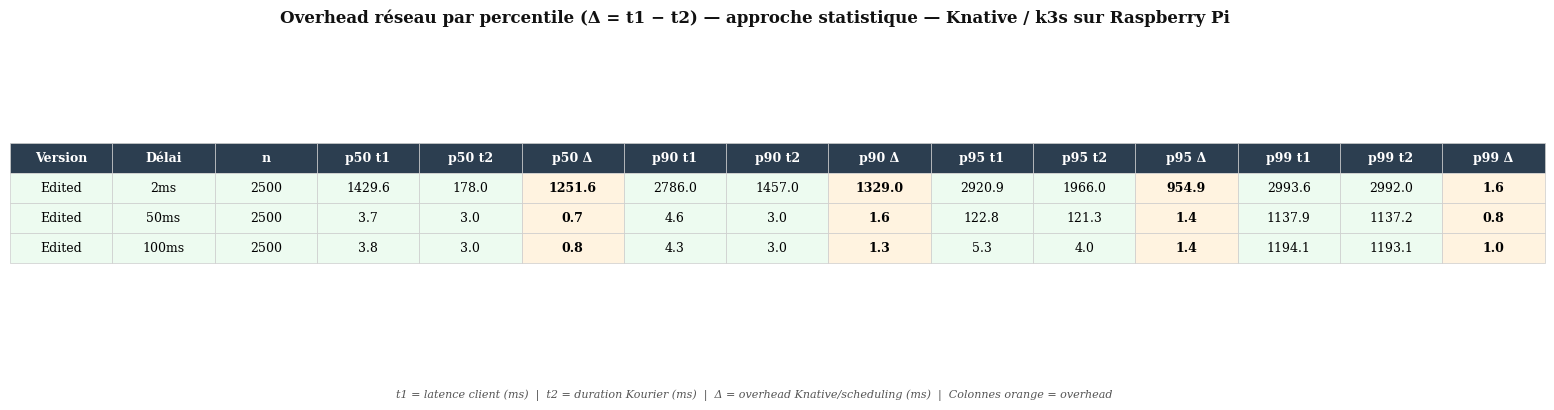

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# ── Configuration ──────────────────────────────────────────────────────────────
DELAYS  = ["10ms","50ms","100ms","200ms","1s"]
PERCS   = [50, 90, 95, 99]
PERC_LABELS = ["p50", "p90", "p95", "p99"]

FILES = {
    "Local": {
        d: {
            "all_data": os.path.join("all_data", f"all_data_decomposed_{d}.csv"),
            "kourier":  os.path.join("kourier",  f"kourier_decomposed_{d}.csv"),
        }
        for d in DELAYS
    },
    "Local 1core": {
        d: {
            "all_data": os.path.join("all_data", f"all_data_decomposed_1core{d}.csv"),
            "kourier":  os.path.join("kourier",  f"kourier_decomposed_1core{d}.csv"),
        }
        for d in DELAYS
    },
    "Hybrid": {
        d: {
            "all_data": os.path.join("all_data", f"all_data_decomposed{d}_hybrid.csv"),
            "kourier":  os.path.join("kourier",  f"kourier_decomposed{d}_hybrid.csv"),
        }
        for d in DELAYS
    },
}

# Colonnes
COL_T1 = {"Local": "latency_ms", "Local 1core": "latency_ms","Hyrbid": "latency_ms"}  # déjà en ms
COL_T2 = "duration_ms"

# ── Chargement ─────────────────────────────────────────────────────────────────
def read_col(filepath: str, col: str) -> pd.Series:
    if not os.path.exists(filepath):
        raise FileNotFoundError(f"Fichier introuvable : {filepath}")
    with open(filepath, "r") as f:
        first_line = f.readline()
    sep = ";" if ";" in first_line else ","
    df = pd.read_csv(filepath, sep=sep)
    if col not in df.columns:
        raise ValueError(f"Colonne '{col}' absente dans {filepath}. Colonnes : {list(df.columns)}")
    return df[col].dropna()

# ── Calcul overhead par percentile (approche statistique) ─────────────────────
rows = []
for version in ["Local", "Hybrid","Local 1core"]:
    for delay in DELAYS:
        try:
            t1 = read_col(FILES[version][delay]["all_data"], COL_T1[version])
            t2 = read_col(FILES[version][delay]["kourier"],  COL_T2)

            row = {
                "Version": version.capitalize(),
                "Délai":   delay,
                "n_t1":    len(t1),
                "n_t2":    len(t2),
            }
            for p, label in zip(PERCS, PERC_LABELS):
                p_t1 = np.percentile(t1, p)
                p_t2 = np.percentile(t2, p)
                row[f"{label}_t1"]       = round(p_t1, 2)
                row[f"{label}_t2"]       = round(p_t2, 2)
                row[f"{label}_overhead"] = round(p_t1 - p_t2, 2)

            rows.append(row)
            print(f"\n{'='*50}")
            print(f"  {version.upper()} — Délai {delay}")
            print(f"{'='*50}")
            print(f"  {'Percentile':<12} {'t1 (ms)':<12} {'t2 (ms)':<12} {'Overhead (ms)'}")
            print(f"  {'-'*50}")
            for p, label in zip(PERCS, PERC_LABELS):
                print(f"  {label:<12} {row[f'{label}_t1']:<12} {row[f'{label}_t2']:<12} {row[f'{label}_overhead']}")

        except (FileNotFoundError, ValueError) as e:
            print(f"⚠️  {e}")

df_perc = pd.DataFrame(rows)

# ── Figure : tableau matplotlib ────────────────────────────────────────────────
col_labels = ["Version", "Délai", "n",
              "p50 t1", "p50 t2", "p50 Δ",
              "p90 t1", "p90 t2", "p90 Δ",
              "p95 t1", "p95 t2", "p95 Δ",
              "p99 t1", "p99 t2", "p99 Δ"]

cell_data = []
for _, r in df_perc.iterrows():
    cell_data.append([
        r["Version"], r["Délai"], int(r["n_t1"]),
        f'{r["p50_t1"]:.1f}', f'{r["p50_t2"]:.1f}', f'{r["p50_overhead"]:.1f}',
        f'{r["p90_t1"]:.1f}', f'{r["p90_t2"]:.1f}', f'{r["p90_overhead"]:.1f}',
        f'{r["p95_t1"]:.1f}', f'{r["p95_t2"]:.1f}', f'{r["p95_overhead"]:.1f}',
        f'{r["p99_t1"]:.1f}', f'{r["p99_t2"]:.1f}', f'{r["p99_overhead"]:.1f}',
    ])

fig, ax = plt.subplots(figsize=(18, 4))
fig.patch.set_facecolor("white")
ax.axis("off")

table = ax.table(
    cellText=cell_data,
    colLabels=col_labels,
    cellLoc="center",
    loc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.1, 1.8)

HEADER_COLOR = "#2C3E50"
ORIG_COLOR   = "#EBF3FF"
EDIT_COLOR   = "#EDFBF0"
DELTA_COLOR  = "#FFF3E0"  # orange clair pour les colonnes overhead Δ

# Indices des colonnes Δ (overhead) : 5, 8, 11, 14
DELTA_COLS = [5, 8, 11, 14]

for (row_idx, col_idx), cell in table.get_celld().items():
    cell.set_edgecolor("#CCCCCC")
    cell.set_linewidth(0.5)
    if row_idx == 0:
        cell.set_facecolor(HEADER_COLOR)
        cell.set_text_props(color="white", fontweight="bold", fontsize=9)
    else:
        version = cell_data[row_idx - 1][0]
        if col_idx in DELTA_COLS:
            cell.set_facecolor(DELTA_COLOR)
            cell.set_text_props(fontweight="bold")
        else:
            cell.set_facecolor(ORIG_COLOR if version == "Original" else EDIT_COLOR)

fig.suptitle(
    "Overhead réseau par percentile (Δ = t1 − t2) — approche statistique — Knative / k3s sur Raspberry Pi",
    fontsize=12, fontweight="bold", color="#111111", y=0.98,
)
fig.text(
    0.5, 0.01,
    "t1 = latence client (ms)  |  t2 = duration Kourier (ms)  |  Δ = overhead Knative/scheduling (ms)  |  Colonnes orange = overhead",
    ha="center", fontsize=8, color="#555555", style="italic",
)

plt.savefig("percentiles_overhead.png", dpi=300, bbox_inches="tight", facecolor="white")
print("\n✅ Tableau sauvegardé : percentiles_overhead.png")

df_perc.to_csv("percentiles_overhead.csv", index=False)
print("✅ CSV exporté : percentiles_overhead.csv")

plt.show()


===== COMPUTING OVERHEAD =====

✓ Local        10ms  p50=3.63 ms | p99=19.90 ms
✓ Local        50ms  p50=8.27 ms | p99=5.75 ms
✓ Local        100ms p50=7.88 ms | p99=29.16 ms
✓ Local        1s    p50=3.47 ms | p99=3.36 ms
✓ Local 1core  10ms  p50=5.34 ms | p99=2.73 ms
✓ Local 1core  50ms  p50=7.78 ms | p99=17.93 ms
✓ Local 1core  100ms p50=7.14 ms | p99=23.00 ms
✓ Local 1core  1s    p50=2.20 ms | p99=172.07 ms
✓ Hybrid       10ms  p50=6.99 ms | p99=4.35 ms
✓ Hybrid       50ms  p50=5.60 ms | p99=4.13 ms
✓ Hybrid       100ms p50=5.59 ms | p99=10.69 ms
✓ Hybrid       1s    p50=5.00 ms | p99=5.49 ms


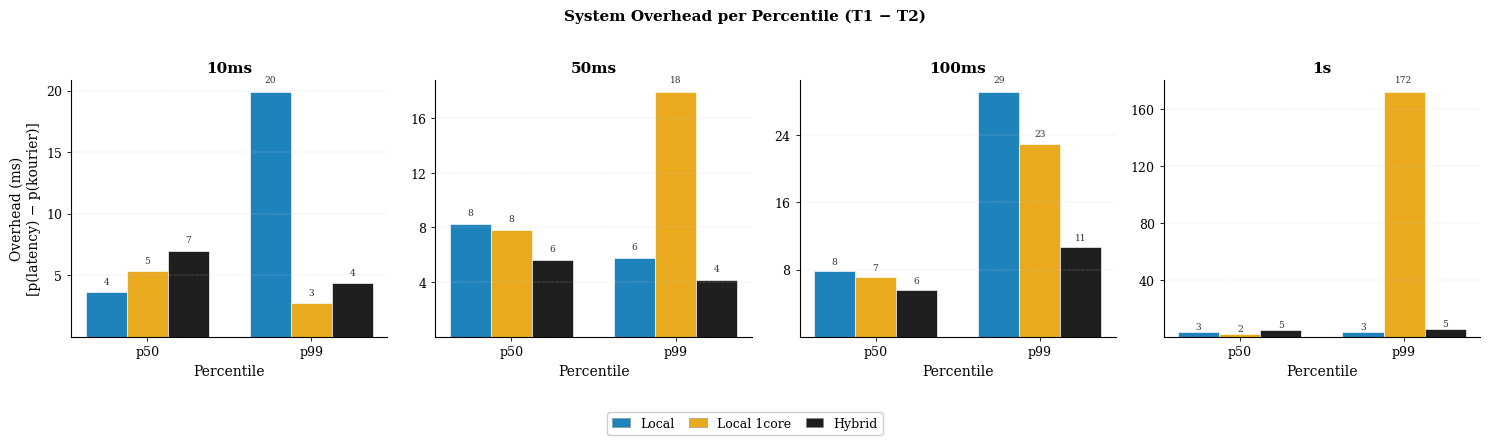


✓ Saved:
  - overhead_barchart.pdf
  - overhead_barchart.png


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import os
from matplotlib.patches import Patch

# ── Typography (OSDI / ACM style) ────────────────────────────────────
plt.rcParams.update({
    "font.family":       "serif",
    "font.serif":        ["Times New Roman", "DejaVu Serif"],
    "font.size":         10,
    "axes.titlesize":    11,
    "axes.labelsize":    10,
    "xtick.labelsize":   9,
    "ytick.labelsize":   9,
    "legend.fontsize":   9,
    "axes.linewidth":    0.8,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "pdf.fonttype":      42,
    "ps.fonttype":       42,
})

# ── Config ────────────────────────────────────────────────────────────
DELAYS = ["10ms", "50ms", "100ms", "1s"]

PERCS = [50, 99]
PERC_LABELS = ["p50", "p99"]

VERSIONS = ["Local", "Local 1core", "Hybrid"]

# ── Files ─────────────────────────────────────────────────────────────
ALL_DATA_FILES = {
    "Local": {
        d: os.path.join("all_data", f"all_data_decomposed_{d}.csv")
        for d in DELAYS
    },

    "Local 1core": {
        d: os.path.join("all_data", f"all_data_decomposed_{d}_1core.csv")
        for d in DELAYS
    },

    "Hybrid": {
        d: os.path.join("all_data", f"all_data_decomposed_{d}_hybrid.csv")
        for d in DELAYS
    },
}

KOURIER_FILES = {
    "Local": {
        d: os.path.join("kourier", f"kourier_decomposed_df_{d}.csv")
        for d in DELAYS
    },

    "Local 1core": {
        d: os.path.join("kourier", f"kourier_decomposed_df_{d}_1core.csv")
        for d in DELAYS
    },

    "Hybrid": {
        d: os.path.join("kourier", f"kourier_decomposed_df_{d}_hybrid.csv")
        for d in DELAYS
    },
}

# ── Colors ────────────────────────────────────────────────────────────
VERSION_COLORS = {
    "Local": "#0072B2",
    "Local 1core": "#E69F00",
    "Hybrid": "#000000",
}

# ── Load percentile ───────────────────────────────────────────────────
def load_percentile(path, col, percentile):
    if not os.path.exists(path):
        raise FileNotFoundError(path)

    df = pd.read_csv(path)

    if col not in df.columns:
        raise ValueError(f"Column '{col}' missing in {path}")

    # garde uniquement status=200 si dispo
    if "status" in df.columns:
        df = df[df["status"] == 200]

    series = pd.to_numeric(df[col], errors="coerce").dropna()

    if len(series) == 0:
        raise ValueError(f"No valid values in {path}")

    return np.percentile(series, percentile)

# ── Compute overhead ──────────────────────────────────────────────────
overhead = {v: {} for v in VERSIONS}

print("\n===== COMPUTING OVERHEAD =====\n")

for version in VERSIONS:
    for delay in DELAYS:

        path_latency = ALL_DATA_FILES[version][delay]
        path_kourier = KOURIER_FILES[version][delay]

        try:
            vals = []

            for p in PERCS:
                latency = load_percentile(path_latency, "latency_ms", p)
                duration = load_percentile(path_kourier, "duration_ms", p)

                vals.append(latency - duration)

            overhead[version][delay] = vals

            print(
                f"✓ {version:<12} {delay:<5} "
                f"p50={vals[0]:.2f} ms | "
                f"p99={vals[1]:.2f} ms"
            )

        except Exception as e:
            print(f"⚠ {version}/{delay} -> {e}")
            overhead[version][delay] = [np.nan] * len(PERCS)

# ── Plot ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(
    1,
    len(DELAYS),
    figsize=(15, 4),
    sharey=False
)

# important quand un seul subplot
if len(DELAYS) == 1:
    axes = [axes]

x = np.arange(len(PERCS))

width = 0.25
offsets = [-width, 0, width]

for i, delay in enumerate(DELAYS):

    ax = axes[i]

    for j, version in enumerate(VERSIONS):

        vals = overhead[version][delay]

        # skip si tout NaN
        if np.all(np.isnan(vals)):
            continue

        xpos = x + offsets[j]

        bars = ax.bar(
            xpos,
            vals,
            width=width,
            color=VERSION_COLORS[version],
            alpha=0.88,
            edgecolor="white",
            linewidth=0.5,
        )

        # annotations
        for bar, val in zip(bars, vals):

            if np.isnan(val):
                continue

            offset = max(abs(val) * 0.03, 0.5)

            ax.text(
                bar.get_x() + bar.get_width() / 2,
                val + offset,
                f"{val:.0f}",
                ha="center",
                va="bottom",
                fontsize=6.5,
                color="#333333",
            )

    ax.set_xticks(x)
    ax.set_xticklabels(PERC_LABELS)

    ax.set_title(
        delay,
        fontweight="bold",
        pad=5
    )

    ax.set_xlabel("Percentile")

    if i == 0:
        ax.set_ylabel(
            "Overhead (ms)\n[p(latency) − p(kourier)]"
        )

    ax.axhline(
        0,
        color="0.40",
        linestyle="--",
        linewidth=0.7,
        zorder=0
    )

    ax.grid(
        True,
        axis="y",
        linestyle=":",
        linewidth=0.35,
        color="0.80"
    )

    ax.tick_params(
        axis="both",
        direction="out",
        length=3,
        width=0.6
    )

    ax.yaxis.set_major_locator(
        ticker.MaxNLocator(
            nbins=5,
            prune="both"
        )
    )

# ── Shared legend ─────────────────────────────────────────────────────
legend_handles = [
    Patch(
        facecolor=VERSION_COLORS[v],
        edgecolor="grey",
        linewidth=0.4,
        alpha=0.88,
        label=v
    )
    for v in VERSIONS
]

fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=3,
    bbox_to_anchor=(0.5, -0.06),
    framealpha=0.95,
    edgecolor="0.80",
    handlelength=1.4,
    columnspacing=1.2,
)

# ── Title ─────────────────────────────────────────────────────────────
fig.suptitle(
    "System Overhead per Percentile "
    "(T1 − T2)",
    fontsize=11,
    fontweight="bold",
    y=1.02
)

plt.tight_layout(rect=[0, 0.06, 1, 1])

# ── Save ──────────────────────────────────────────────────────────────
fig.savefig(
    "overhead_barchart.pdf",
    dpi=300,
    bbox_inches="tight"
)

fig.savefig(
    "overhead_barchart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\n✓ Saved:")
print("  - overhead_barchart.pdf")
print("  - overhead_barchart.png")

In [7]:
import pandas as pd
import numpy as np
import os

DELAYS = ["10ms", "50ms", "100ms", "200ms", "1s"]

# ── Teste les deux structures de chemins possibles ───────────────────────────
PATH_VARIANTS = [
    # (label, all_data_pattern, kourier_pattern)
    ("flat",
     "all_data_decomposed_{d}.csv",
     "kourier_decomposed_{d}.csv"),
    ("subdir",
     os.path.join("all_data", "all_data_decomposed_{d}.csv"),
     os.path.join("kourier",  "kourier_decomposed_{d}.csv")),
    ("hybrid_flat",
     "all_data_decomposed_{d}_hybrid.csv",
     "kourier_decomposed_{d}_hybrid.csv"),
]

print("=" * 60)
print("FILE EXISTENCE CHECK")
print("=" * 60)
for label, pat1, pat2 in PATH_VARIANTS:
    for d in DELAYS:
        p1 = pat1.format(d=d)
        p2 = pat2.format(d=d)
        e1 = os.path.exists(p1)
        e2 = os.path.exists(p2)
        if e1 or e2:
            print(f"[{label}] {d}: all_data={'OK' if e1 else 'MISSING'} | kourier={'OK' if e2 else 'MISSING'}")

print()
print("=" * 60)
print("COLUMN + VALUE SAMPLE (first found files)")
print("=" * 60)

found = []
for f in os.listdir("."):
    if f.endswith(".csv"):
        found.append(f)
for subdir in ["all_data", "kourier"]:
    if os.path.isdir(subdir):
        for f in os.listdir(subdir):
            if f.endswith(".csv"):
                found.append(os.path.join(subdir, f))

for path in sorted(found)[:8]:
    try:
        df = pd.read_csv(path)
        print(f"\n{path}")
        print(f"  columns : {list(df.columns)}")
        for col in ["latency_ms", "duration_ms", "latency", "duration"]:
            if col in df.columns:
                s = df[col].dropna()
                print(f"  {col:15s}: n={len(s):5d}  min={s.min():.3f}  p50={np.percentile(s,50):.3f}  p99={np.percentile(s,99):.3f}  max={s.max():.3f}")
    except Exception as e:
        print(f"{path} → ERROR: {e}")

FILE EXISTENCE CHECK
[subdir] 10ms: all_data=OK | kourier=MISSING
[subdir] 50ms: all_data=OK | kourier=MISSING
[subdir] 100ms: all_data=OK | kourier=MISSING
[subdir] 200ms: all_data=OK | kourier=MISSING
[subdir] 1s: all_data=OK | kourier=MISSING

COLUMN + VALUE SAMPLE (first found files)

all_data/all_data_decomposed_100ms.csv
  columns : ['index', 'request_id', 'function', 'size', 'type', 'status', 'latency_ms', 'ttfb_ms', 'output_transfer_ms', 'execution_time_ms', 'system_overhead_ms', 'in_flight']
  latency_ms     : n=20010  min=22.320  p50=133.880  p99=2448.030  max=17097.040

all_data/all_data_decomposed_100ms_1core.csv
  columns : ['index', 'request_id', 'function', 'size', 'type', 'status', 'latency_ms', 'ttfb_ms', 'output_transfer_ms', 'execution_time_ms', 'system_overhead_ms', 'in_flight']
  latency_ms     : n=20010  min=22.480  p50=140.145  p99=2181.905  max=9188.040

all_data/all_data_decomposed_100ms_hybrid.csv
  columns : ['index', 'request_id', 'function', 'size', 'type',